In [60]:
# Install KaggleHub if required
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("kagglehub") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub", "-q"])

print("KaggleHub is available.")

KaggleHub is available.


In [61]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")

Libraries imported successfully.


# Load the Datasets Directly from Kaggle

The source datasets are downloaded into KaggleHub's local cache when this notebook runs. The code then automatically identifies the appropriate CSV files instead of assuming a manually downloaded filename.

In [62]:
AIR_HANDLE = "rohanrao/air-quality-data-in-india"
CROP_HANDLE = "abhinand05/crop-production-in-india"

air_path = Path(kagglehub.dataset_download(AIR_HANDLE))
crop_path = Path(kagglehub.dataset_download(CROP_HANDLE))

air_files = sorted([p for p in air_path.rglob("*") if p.is_file()])
crop_files = sorted([p for p in crop_path.rglob("*") if p.is_file()])

print("Air dataset files:")
for p in air_files:
    print(" -", p.name)

print("\nCrop dataset files:")
for p in crop_files:
    print(" -", p.name)

Air dataset files:
 - city_day.csv
 - city_hour.csv
 - station_day.csv
 - station_hour.csv
 - stations.csv

Crop dataset files:
 - crop_production.csv


In [63]:
def find_named_file(files, preferred_names, required_terms=None):
    name_map = {p.name.lower(): p for p in files}

    for name in preferred_names:
        if name.lower() in name_map:
            return name_map[name.lower()]

    if required_terms:
        for p in files:
            name = p.name.lower()
            if all(term.lower() in name for term in required_terms):
                return p

    raise FileNotFoundError(
        f"No suitable file found. Available files: {[p.name for p in files]}"
    )

# Air-quality dataset commonly contains city_day.csv and stations.csv
air_city_file = find_named_file(
    air_files,
    preferred_names=["city_day.csv"],
    required_terms=["city", "day"]
)

stations_file = find_named_file(
    air_files,
    preferred_names=["stations.csv"],
    required_terms=["station"]
)

# Automatically identify the crop CSV based on its column structure
crop_csvs = [p for p in crop_files if p.suffix.lower() == ".csv"]
crop_file = None

for candidate in crop_csvs:
    try:
        preview = pd.read_csv(candidate, nrows=5)
        normalized = {
            re.sub(r"[^a-z0-9]+", "", str(c).lower())
            for c in preview.columns
        }
        if (
            {"crop", "area", "production"}.issubset(normalized)
            and any(x in normalized for x in ["state", "statename"])
            and any(x in normalized for x in ["year", "cropyear"])
        ):
            crop_file = candidate
            break
    except Exception:
        continue

if crop_file is None:
    raise FileNotFoundError(
        f"Could not identify crop CSV. Available CSVs: {[p.name for p in crop_csvs]}"
    )

print("Selected air file:", air_city_file.name)
print("Selected station file:", stations_file.name)
print("Selected crop file:", crop_file.name)

Selected air file: city_day.csv
Selected station file: stations.csv
Selected crop file: crop_production.csv


In [64]:
air_raw = pd.read_csv(air_city_file)
stations_raw = pd.read_csv(stations_file)
crop_raw = pd.read_csv(crop_file)

print("Air-quality shape:", air_raw.shape)
print("Station metadata shape:", stations_raw.shape)
print("Crop-production shape:", crop_raw.shape)

display(air_raw.head())
display(stations_raw.head())
display(crop_raw.head())

Air-quality shape: (29531, 16)
Station metadata shape: (230, 5)
Crop-production shape: (246091, 7)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.920,18.220,17.150,NaN,0.920,27.640,133.360,0.000,0.020,0.000,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.970,15.690,16.460,NaN,0.970,24.550,34.060,3.680,5.500,3.770,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.400,19.300,29.700,NaN,17.400,29.070,30.700,6.800,16.400,2.250,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.700,18.480,17.970,NaN,1.700,18.590,36.080,4.430,10.140,1.000,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.100,21.420,37.760,NaN,22.100,39.330,39.310,7.010,18.890,2.780,NaN,NaN


,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,"1,254.000","2,000.000"
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.000,1.000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.000,321.000
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.000,641.000
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.000,165.000


# Lab 1 — Data Preprocessing and Visualisation

## Task 1 — First-Impression Data Profile

A reliable first inspection should answer:
- How large is the dataset?
- What are the columns and data types?
- Which columns contain missing values?
- Are exact duplicate records present?
- What ranges do numerical columns have?
- How many unique categories exist?
- What date/year coverage is available?
- Are the analytical keys such as City, State and Year present?

The following reusable function creates a structured profile for each dataset.

In [65]:
def structured_profile(df, name):
    print("=" * 90)
    print(f"STRUCTURED PROFILE: {name}")
    print("=" * 90)

    print(f"Rows: {len(df):,}")
    print(f"Columns: {df.shape[1]:,}")
    print("\nColumns:")
    print(list(df.columns))

    print("\nData types:")
    display(df.dtypes.to_frame("Data Type"))

    missing = pd.DataFrame({
        "Missing Count": df.isna().sum(),
        "Missing %": df.isna().mean() * 100
    }).sort_values("Missing %", ascending=False)

    print("\nMissing-value summary:")
    display(missing)

    print(f"\nExact duplicate rows: {df.duplicated().sum():,}")

    numeric_cols = df.select_dtypes(include=np.number).columns
    if len(numeric_cols):
        print("\nNumerical summary:")
        display(df[numeric_cols].describe().T)

    object_cols = df.select_dtypes(exclude=np.number).columns
    if len(object_cols):
        rows = []
        for col in object_cols:
            vals = df[col].dropna().astype(str).unique()
            rows.append({
                "Column": col,
                "Unique Values": len(vals),
                "Examples": ", ".join(vals[:6])
            })
        print("\nCategorical summary:")
        display(pd.DataFrame(rows))

    print("\nSample rows:")
    display(df.head())

structured_profile(air_raw, "Air Quality")
structured_profile(crop_raw, "Crop Production")

STRUCTURED PROFILE: Air Quality
Rows: 29,531
Columns: 16

Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data types:


,Data Type
City,str
Date,str
PM2.5,float64
PM10,float64
NO,float64
NO2,float64
NOx,float64
NH3,float64
CO,float64
SO2,float64



Missing-value summary:


,Missing Count,Missing %
Xylene,18109,61.322
PM10,11140,37.723
NH3,10328,34.973
Toluene,8041,27.229
Benzene,5623,19.041
AQI,4681,15.851
AQI_Bucket,4681,15.851
PM2.5,4598,15.570
NOx,4185,14.172
O3,4022,13.620



Exact duplicate rows: 0

Numerical summary:


...

,count,mean,std,min,25%,50%,75%,max
Crop_Year,"246,091.000","2,005.643",4.952,"1,997.000","2,002.000","2,006.000","2,010.000","2,015.000"
Area,"246,091.000","12,002.821","50,523.404",0.040,80.000,582.000,"4,392.000","8,580,100.000"
Production,"242,361.000","582,503.442","17,065,813.172",0.000,88.000,729.000,"7,023.000","1,250,800,000.000"



Categorical summary:


,Column,Unique Values,Examples
0,State_Name,33,"Andaman and Nicobar Islands, Andhra Pradesh, A..."
1,District_Name,646,"NICOBARS, NORTH AND MIDDLE ANDAMAN, SOUTH ANDA..."
2,Season,6,"Kharif , Whole Year , Autumn , Rabi ..."
3,Crop,124,"Arecanut, Other Kharif pulses, Rice, Banana, C..."



Sample rows:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,"1,254.000","2,000.000"
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.000,1.000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.000,321.000
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.000,641.000
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.000,165.000


In [66]:
# Inspect actual time coverage

air_dates_temp = pd.to_datetime(air_raw["Date"], errors="coerce")

crop_col_lookup = {
    re.sub(r"[^a-z0-9]+", "", str(c).lower()): c
    for c in crop_raw.columns
}

crop_year_source = None
for key in ["cropyear", "year"]:
    if key in crop_col_lookup:
        crop_year_source = crop_col_lookup[key]
        break

print("Air-quality date range:",
      air_dates_temp.min(),
      "to",
      air_dates_temp.max())

if crop_year_source is not None:
    crop_year_temp = pd.to_numeric(crop_raw[crop_year_source], errors="coerce")
    print(
        "Crop-production year range:",
        int(crop_year_temp.min()),
        "to",
        int(crop_year_temp.max())
    )

Air-quality date range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00
Crop-production year range: 1997 to 2015


### Task 1 — Concern After Inspection

Several issues require attention before modelling. The air dataset contains city-level daily readings, whereas the crop dataset contains agricultural records at a different geographical and yearly level, so they cannot be directly joined row-by-row. Missing measurements are also expected in several pollution columns, and simply deleting every incomplete row would waste substantial information.

The two datasets can also differ in state naming, geographical coverage and year coverage. Therefore, state names must be standardised and cross-dataset analysis must be restricted to the years that actually overlap.

Another important issue is that the main air-quality file contains City but not State. The State value must therefore be derived from the station metadata before state-level comparison is possible.

## Task 2 — Missing-Value Treatment

### Air-quality decisions
- **City, Date and AQI:** rows missing these fields are dropped because they cannot answer the core analytical questions.
- **Pollutants:** missing pollutant measurements are filled using the median for the same city. If an entire city lacks enough measurements, the overall median is used as a fallback. The median is preferred because pollution variables are often right-skewed and can contain extremes.
- **AQI_Bucket:** not required for the numerical analysis, so missing labels do not need artificial replacement.

### Crop-production decisions
- **State, Year and Crop:** rows missing these keys cannot be grouped reliably and are dropped.
- **Area:** missing, zero or negative values are invalid for yield analysis and are removed.
- **Production:** missing values are dropped rather than filled with a global mean because production differs greatly by crop, year and state.
- **Season/District:** if missing, these descriptive fields may be labelled `"Unknown"` because the state-year totals remain usable.

In [67]:
air = air_raw.copy()
crop = crop_raw.copy()

# Standardise crop column names
crop_rename = {}

for col in crop.columns:
    key = re.sub(r"[^a-z0-9]+", "", str(col).lower())
    mapping = {
        "statename": "State",
        "state": "State",
        "districtname": "District",
        "district": "District",
        "cropyear": "Year",
        "year": "Year",
        "season": "Season",
        "crop": "Crop",
        "area": "Area",
        "production": "Production"
    }
    if key in mapping:
        crop_rename[col] = mapping[key]

crop = crop.rename(columns=crop_rename)

required_crop = {"State", "Year", "Crop", "Area", "Production"}
missing_required = required_crop - set(crop.columns)

if missing_required:
    raise ValueError(f"Missing required crop columns: {missing_required}")

air["Date"] = pd.to_datetime(air["Date"], errors="coerce")
air["AQI"] = pd.to_numeric(air["AQI"], errors="coerce")

crop["Year"] = pd.to_numeric(crop["Year"], errors="coerce")
crop["Area"] = pd.to_numeric(crop["Area"], errors="coerce")
crop["Production"] = pd.to_numeric(crop["Production"], errors="coerce")

print("AIR null counts before treatment:")
display(air.isna().sum().to_frame("Null Count"))

print("CROP null counts before treatment:")
display(crop.isna().sum().to_frame("Null Count"))

AIR null counts before treatment:


,Null Count
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


CROP null counts before treatment:


,Null Count
State,0
District,0
Year,0
Season,0
Crop,0
Area,0
Production,3730


In [68]:
# Air missing-value treatment

air_before_missing = air.copy()

air = air.dropna(subset=["City", "Date", "AQI"]).copy()

pollutant_candidates = [
    "PM2.5", "PM10", "NO", "NO2", "NOx", "NH3",
    "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene"
]

pollutant_cols = [c for c in pollutant_candidates if c in air.columns]

for col in pollutant_cols:
    air[col] = pd.to_numeric(air[col], errors="coerce")
    city_median = air.groupby("City")[col].transform("median")
    air[col] = air[col].fillna(city_median)
    air[col] = air[col].fillna(air[col].median())

print("AIR null counts after treatment:")
display(air.isna().sum().to_frame("Null Count"))

AIR null counts after treatment:


,Null Count
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


In [69]:
# Crop missing-value treatment

crop_before_missing = crop.copy()

crop = crop.dropna(
    subset=["State", "Year", "Crop", "Area", "Production"]
).copy()

crop = crop[
    (crop["Area"] > 0) &
    (crop["Production"] >= 0)
].copy()

crop["Year"] = crop["Year"].astype(int)

if "Season" in crop.columns:
    crop["Season"] = crop["Season"].fillna("Unknown")

if "District" in crop.columns:
    crop["District"] = crop["District"].fillna("Unknown")

print("CROP null counts after treatment:")
display(crop.isna().sum().to_frame("Null Count"))

display(pd.DataFrame({
    "Dataset": ["Air Quality", "Crop Production"],
    "Rows Before": [len(air_before_missing), len(crop_before_missing)],
    "Rows After": [len(air), len(crop)],
    "Rows Removed": [
        len(air_before_missing) - len(air),
        len(crop_before_missing) - len(crop)
    ]
}))

CROP null counts after treatment:


,Null Count
State,0
District,0
Year,0
Season,0
Crop,0
Area,0
Production,0


,Dataset,Rows Before,Rows After,Rows Removed
0,Air Quality,29531,24850,4681
1,Crop Production,246091,242361,3730


## Task 3 — Standardise State Names and Remove Duplicates

A merge requires identical keys. Variants such as extra spaces, different capitalisation, `"Orissa"` versus `"Odisha"`, or `"Uttaranchal"` versus `"Uttarakhand"` would otherwise fail to match.

The approach is:
1. Use station metadata to map each air-quality City to a State.
2. Strip whitespace and collapse repeated spaces.
3. Standardise case.
4. Resolve a small set of common historical aliases.
5. Record all observed changes.
6. Remove exact duplicate rows and show record counts before and after.

In [70]:
stations = stations_raw.copy()
stations.columns = [str(c).strip() for c in stations.columns]

if not {"City", "State"}.issubset(stations.columns):
    raise ValueError("Station metadata must contain City and State columns.")

station_lookup = (
    stations[["City", "State"]]
    .dropna()
    .assign(
        City=lambda d: d["City"].astype(str).str.strip(),
        State=lambda d: d["State"].astype(str).str.strip()
    )
    .drop_duplicates()
)

ambiguous = (
    station_lookup.groupby("City")["State"].nunique()
    .loc[lambda s: s > 1]
)

print("Cities mapped to more than one state:", len(ambiguous))
if len(ambiguous):
    display(ambiguous)

city_to_state = (
    station_lookup.drop_duplicates("City")
    .set_index("City")["State"]
    .to_dict()
)

air["City"] = air["City"].astype(str).str.strip()
air["State"] = air["City"].map(city_to_state)

print(
    f"State mapping coverage: "
    f"{air['State'].notna().mean() * 100:.2f}% of air rows"
)

Cities mapped to more than one state: 0
State mapping coverage: 100.00% of air rows


In [71]:
STATE_ALIASES = {
    "Nct Of Delhi": "Delhi",
    "National Capital Territory Of Delhi": "Delhi",
    "Delhi Nct": "Delhi",
    "Orissa": "Odisha",
    "Uttaranchal": "Uttarakhand",
    "Pondicherry": "Puducherry",
    "Andaman And Nicobar Islands": "Andaman and Nicobar Islands",
    "Jammu And Kashmir": "Jammu and Kashmir",
    "Dadra And Nagar Haveli": "Dadra and Nagar Haveli"
}

def standardise_state(series):
    original = series.copy()

    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace(r"\s*&\s*", " and ", regex=True)
        .str.title()
        .replace(STATE_ALIASES)
    )

    change_log = (
        pd.DataFrame({
            "Original": original,
            "Cleaned": cleaned
        })
        .dropna()
        .loc[lambda d:
             d["Original"].astype(str) != d["Cleaned"].astype(str)]
        .drop_duplicates()
        .sort_values(["Original", "Cleaned"])
    )

    return cleaned, change_log

air["State"], air_changes = standardise_state(air["State"])
crop["State"], crop_changes = standardise_state(crop["State"])

print("State-name inconsistencies corrected in AIR data:")
display(
    air_changes if len(air_changes)
    else pd.DataFrame({"Result": ["No additional variants found."]})
)

print("State-name inconsistencies corrected in CROP data:")
display(
    crop_changes if len(crop_changes)
    else pd.DataFrame({"Result": ["No variants found."]})
)

State-name inconsistencies corrected in AIR data:


,Result
0,No additional variants found.


State-name inconsistencies corrected in CROP data:


,Original,Cleaned
73965,Jammu and Kashmir,Jammu and Kashmir
191215,Telangana,Telangana


In [72]:
air_before_dupes = len(air)
crop_before_dupes = len(crop)

air_dupes = int(air.duplicated().sum())
crop_dupes = int(crop.duplicated().sum())

air = air.drop_duplicates().copy()
crop = crop.drop_duplicates().copy()

display(pd.DataFrame({
    "Dataset": ["Air Quality", "Crop Production"],
    "Rows Before": [air_before_dupes, crop_before_dupes],
    "Exact Duplicates": [air_dupes, crop_dupes],
    "Rows After": [len(air), len(crop)]
}))

air_states = set(air["State"].dropna().unique())
crop_states = set(crop["State"].dropna().unique())

print("\nStates found in both datasets:")
print(sorted(air_states & crop_states))

print("\nStates only in air-quality data:")
print(sorted(air_states - crop_states))

print("\nStates only in crop-production data:")
print(sorted(crop_states - air_states))

,Dataset,Rows Before,Exact Duplicates,Rows After
0,Air Quality,24850,0,24850
1,Crop Production,242361,0,242361



States found in both datasets:
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

States only in air-quality data:
['Delhi']

States only in crop-production data:
['Andaman and Nicobar Islands', 'Arunachal Pradesh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Himachal Pradesh', 'Jammu and Kashmir', 'Manipur', 'Nagaland', 'Puducherry', 'Sikkim', 'Tripura', 'Uttarakhand']


### Task 3 Observation
After state-name standardisation, the intersection printed above contains the states that can be matched reliably. States appearing only in one source are retained as documented coverage differences rather than being incorrectly force-matched.

## Task 4 — Where Do Most Cities Sit on the AQI Scale?

Two plots are used:

- A **histogram** shows where AQI observations cluster and whether the distribution is skewed.
- A **box plot** highlights the median, spread and unusually extreme values.

Together, they reveal whether the mean is representative or whether unusually high observations are pulling it upward.

,Statistic,Value
0,Mean AQI,166.464
1,Median AQI,118.000
2,Skewness,3.397


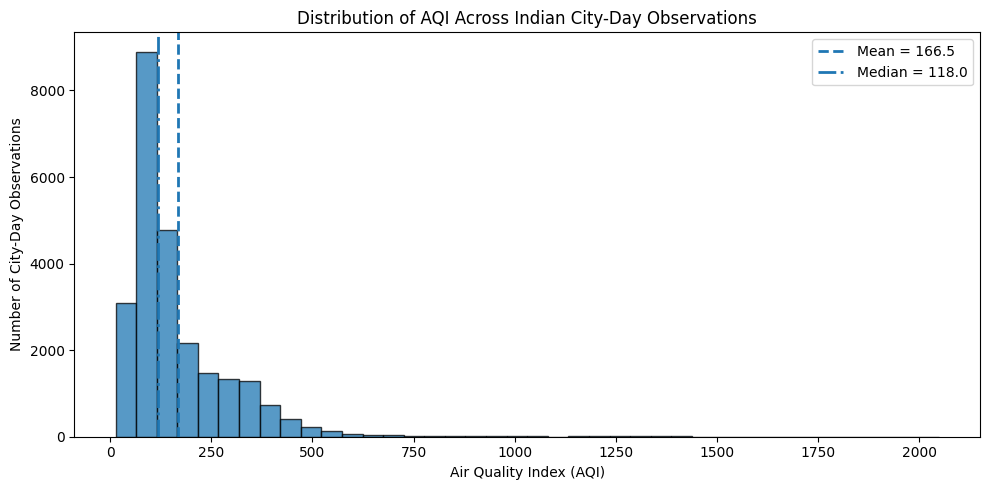

In [73]:
air_pre_outlier = air.copy()

aqi_mean = air_pre_outlier["AQI"].mean()
aqi_median = air_pre_outlier["AQI"].median()
aqi_skew = air_pre_outlier["AQI"].skew()

display(pd.DataFrame({
    "Statistic": ["Mean AQI", "Median AQI", "Skewness"],
    "Value": [aqi_mean, aqi_median, aqi_skew]
}))

plt.figure(figsize=(10, 5))
plt.hist(
    air_pre_outlier["AQI"].dropna(),
    bins=40,
    edgecolor="black",
    alpha=0.75
)
plt.axvline(aqi_mean, linestyle="--", linewidth=2,
            label=f"Mean = {aqi_mean:.1f}")
plt.axvline(aqi_median, linestyle="-.", linewidth=2,
            label=f"Median = {aqi_median:.1f}")
plt.xlabel("Air Quality Index (AQI)")
plt.ylabel("Number of City-Day Observations")
plt.title("Distribution of AQI Across Indian City-Day Observations")
plt.legend()
plt.tight_layout()
plt.show()

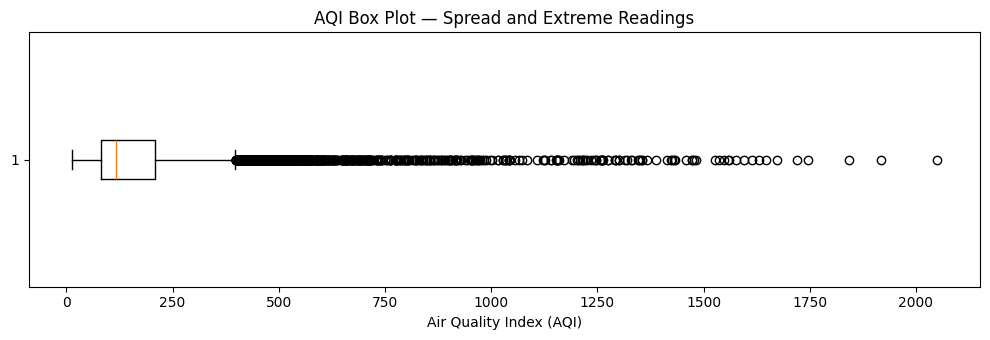

Observation 1: Mean AQI = 166.5 and median AQI = 118.0. A noticeably higher mean suggests high readings are pulling the public-facing average upward.
Observation 2: AQI skewness = 3.40. The positive skew indicates a long high-pollution tail.


In [74]:
plt.figure(figsize=(10, 3.5))
plt.boxplot(air_pre_outlier["AQI"].dropna(), vert=False, showfliers=True)
plt.xlabel("Air Quality Index (AQI)")
plt.title("AQI Box Plot — Spread and Extreme Readings")
plt.tight_layout()
plt.show()

print(
    f"Observation 1: Mean AQI = {aqi_mean:.1f} and median AQI = "
    f"{aqi_median:.1f}. A noticeably higher mean suggests high readings "
    "are pulling the public-facing average upward."
)

print(
    f"Observation 2: AQI skewness = {aqi_skew:.2f}. "
    + (
        "The positive skew indicates a long high-pollution tail."
        if aqi_skew > 0
        else "The distribution is not strongly right-skewed."
    )
)

## Task 5 — Extreme AQI Values

### Detection method
The **Interquartile Range (IQR)** method is used because it is robust to skewed distributions and does not assume normality.

- IQR = Q3 − Q1
- Lower fence = Q1 − 1.5 × IQR
- Upper fence = Q3 + 1.5 × IQR

### Treatment
Instead of deleting whole records, extreme AQI values are winsorised by capping them at the IQR boundaries. This preserves the associated city, date and pollutant information while limiting the influence of highly unusual values.

The uncapped original AQI remains stored for auditability.

In [75]:
q1 = air_pre_outlier["AQI"].quantile(0.25)
q3 = air_pre_outlier["AQI"].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

extreme_mask = (
    (air_pre_outlier["AQI"] < lower_fence) |
    (air_pre_outlier["AQI"] > upper_fence)
)

print(f"Q1 = {q1:.2f}")
print(f"Q3 = {q3:.2f}")
print(f"IQR = {iqr:.2f}")
print(f"Lower fence = {lower_fence:.2f}")
print(f"Upper fence = {upper_fence:.2f}")
print(f"Extreme values detected = {extreme_mask.sum():,}")
print(
    f"Percentage affected = "
    f"{extreme_mask.mean() * 100:.2f}%"
)

display(
    air_pre_outlier.loc[
        extreme_mask,
        ["City", "State", "Date", "AQI"]
    ]
    .sort_values("AQI", ascending=False)
    .head(20)
)

Q1 = 81.00
Q3 = 208.00
IQR = 127.00
Lower fence = -109.50
Upper fence = 398.50
Extreme values detected = 1,358
Percentage affected = 5.46%


,City,State,Date,AQI
1145,Ahmedabad,Gujarat,2018-02-19,"2,049.000"
1136,Ahmedabad,Gujarat,2018-02-10,"1,917.000"
560,Ahmedabad,Gujarat,2016-07-14,"1,842.000"
1048,Ahmedabad,Gujarat,2017-11-14,"1,747.000"
1463,Ahmedabad,Gujarat,2019-01-03,"1,719.000"
1417,Ahmedabad,Gujarat,2018-11-18,"1,672.000"
1420,Ahmedabad,Gujarat,2018-11-21,"1,646.000"
1407,Ahmedabad,Gujarat,2018-11-08,"1,630.000"
1127,Ahmedabad,Gujarat,2018-02-01,"1,613.000"
1746,Ahmedabad,Gujarat,2019-10-13,"1,595.000"


In [76]:
air = air_pre_outlier.copy()
air["AQI_Original"] = air["AQI"]
air["AQI"] = air["AQI"].clip(lower=lower_fence, upper=upper_fence)

affected = int((air["AQI"] != air["AQI_Original"]).sum())

print(f"AQI values capped: {affected:,}")
print(f"Maximum before: {air['AQI_Original'].max():.2f}")
print(f"Maximum after: {air['AQI'].max():.2f}")
print(f"Mean before: {air['AQI_Original'].mean():.2f}")
print(f"Mean after: {air['AQI'].mean():.2f}")

AQI values capped: 1,358
Maximum before: 2049.00
Maximum after: 398.50
Mean before: 166.46
Mean after: 157.34


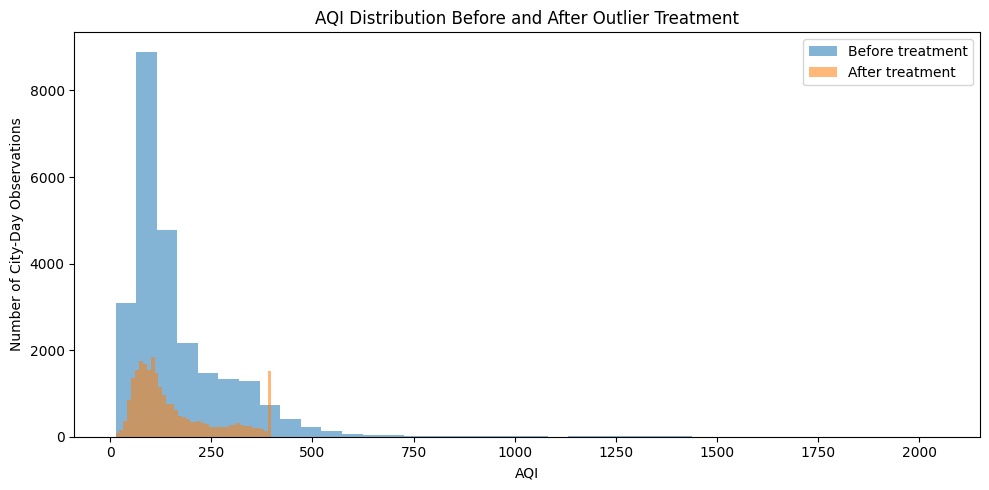

In [77]:
plt.figure(figsize=(10, 5))
plt.hist(
    air["AQI_Original"].dropna(),
    bins=40,
    alpha=0.55,
    label="Before treatment"
)
plt.hist(
    air["AQI"].dropna(),
    bins=40,
    alpha=0.55,
    label="After treatment"
)
plt.xlabel("AQI")
plt.ylabel("Number of City-Day Observations")
plt.title("AQI Distribution Before and After Outlier Treatment")
plt.legend()
plt.tight_layout()
plt.show()

# Lab 2 — Data Exploration and Inferences

## Task 6 — Is India's Air Getting Better or Worse Over Time?

The Date column is converted to a true datetime value and the year is extracted. Mean AQI is then calculated for each year.

A **line chart** is used because it communicates change over time clearly to a non-technical audience. The most and least polluted years are highlighted.

,Year,Mean_AQI
0,2015,203.088
1,2016,189.872
2,2017,173.627
3,2018,166.087
4,2019,147.652
5,2020,111.771


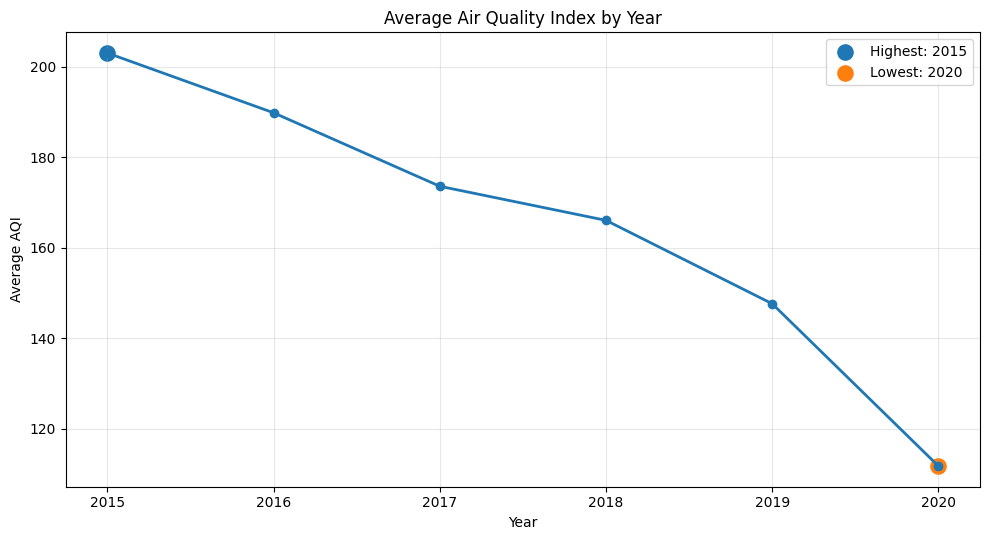

In [78]:
air["Year"] = air["Date"].dt.year
air["Month"] = air["Date"].dt.month

annual_aqi = (
    air.groupby("Year", as_index=False)["AQI"]
    .mean()
    .rename(columns={"AQI": "Mean_AQI"})
    .sort_values("Year")
)

most_polluted = annual_aqi.loc[annual_aqi["Mean_AQI"].idxmax()]
least_polluted = annual_aqi.loc[annual_aqi["Mean_AQI"].idxmin()]

display(annual_aqi)

plt.figure(figsize=(10, 5.5))
plt.plot(
    annual_aqi["Year"],
    annual_aqi["Mean_AQI"],
    marker="o",
    linewidth=2
)

plt.scatter(
    most_polluted["Year"],
    most_polluted["Mean_AQI"],
    s=120,
    label=f"Highest: {int(most_polluted['Year'])}"
)
plt.scatter(
    least_polluted["Year"],
    least_polluted["Mean_AQI"],
    s=120,
    label=f"Lowest: {int(least_polluted['Year'])}"
)

plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.title("Average Air Quality Index by Year")
plt.xticks(annual_aqi["Year"].astype(int))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
first_year = int(annual_aqi.iloc[0]["Year"])
last_year = int(annual_aqi.iloc[-1]["Year"])
first_aqi = float(annual_aqi.iloc[0]["Mean_AQI"])
last_aqi = float(annual_aqi.iloc[-1]["Mean_AQI"])

change_pct = ((last_aqi - first_aqi) / first_aqi) * 100

direction = (
    "improved" if change_pct < -2
    else "worsened" if change_pct > 2
    else "remained broadly stable"
)

print(
    f"Journalist response: In the available dataset, average air quality "
    f"{direction} overall between {first_year} and {last_year}. "
    f"Mean AQI changed from {first_aqi:.1f} to {last_aqi:.1f}, which is "
    f"a {abs(change_pct):.1f}% "
    f"{'decrease' if change_pct < 0 else 'increase' if change_pct > 0 else 'change'}. "
    f"The most polluted year was {int(most_polluted['Year'])} "
    f"(mean AQI {most_polluted['Mean_AQI']:.1f}), while the least polluted "
    f"was {int(least_polluted['Year'])} "
    f"(mean AQI {least_polluted['Mean_AQI']:.1f}). "
    "This describes the monitored cities in this dataset, but it does not prove "
    "that a specific government policy caused the observed change."
)

Journalist response: In the available dataset, average air quality improved overall between 2015 and 2020. Mean AQI changed from 203.1 to 111.8, which is a 45.0% decrease. The most polluted year was 2015 (mean AQI 203.1), while the least polluted was 2020 (mean AQI 111.8). This describes the monitored cities in this dataset, but it does not prove that a specific government policy caused the observed change.


### Task 6 Limitation
The selected Kaggle air-quality dataset covers 2015–2020, so it cannot support a full eight-year post-2018 policy evaluation. Conclusions must be limited to the years actually present.

## Task 7 — Is Air Quality Worse During October–December?

Monthly aggregation is used because it makes the October, November and December pattern directly visible. The average AQI during October–December is also compared with the January–September average.

This tests the NGO's descriptive claim but does not prove that crop-residue burning caused the difference.

,Month,Mean_AQI,Month_Name
0,1,216.862,Jan
1,2,188.159,Feb
2,3,154.014,Mar
3,4,137.502,Apr
4,5,133.716,May
5,6,117.547,Jun
6,7,107.440,Jul
7,8,108.903,Aug
8,9,111.503,Sep
9,10,174.176,Oct


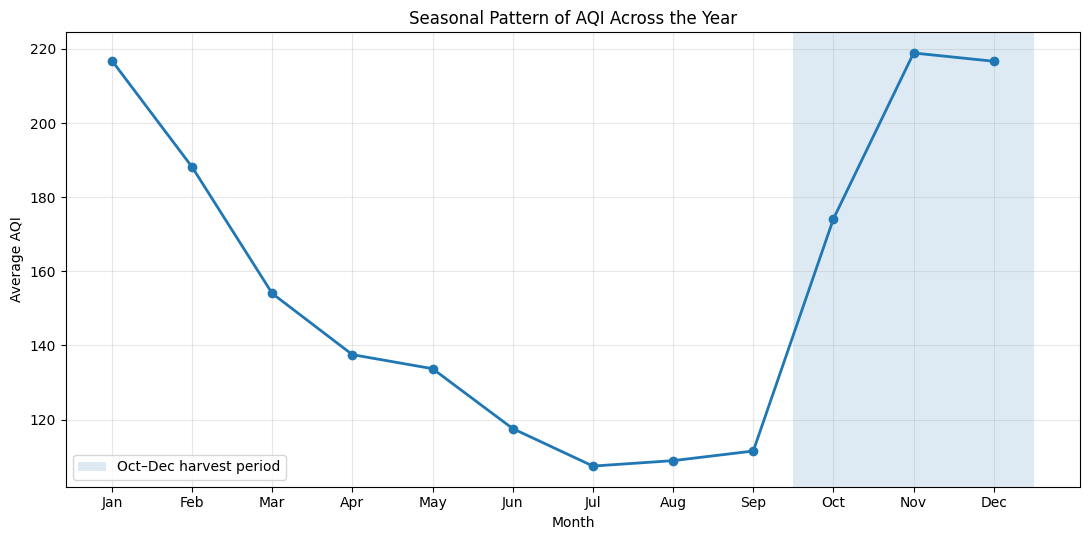

In [80]:
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

monthly_aqi = (
    air.groupby("Month", as_index=False)["AQI"]
    .mean()
    .rename(columns={"AQI": "Mean_AQI"})
)

monthly_aqi["Month_Name"] = monthly_aqi["Month"].map(month_names)
display(monthly_aqi)

plt.figure(figsize=(11, 5.5))
plt.plot(
    monthly_aqi["Month"],
    monthly_aqi["Mean_AQI"],
    marker="o",
    linewidth=2
)
plt.axvspan(9.5, 12.5, alpha=0.15, label="Oct–Dec harvest period")
plt.xticks(range(1, 13), [month_names[i] for i in range(1, 13)])
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.title("Seasonal Pattern of AQI Across the Year")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [81]:
harvest_mean = air.loc[
    air["Month"].isin([10, 11, 12]), "AQI"
].mean()

other_mean = air.loc[
    ~air["Month"].isin([10, 11, 12]), "AQI"
].mean()

difference = harvest_mean - other_mean
pct_difference = difference / other_mean * 100

supports = difference > 0

print(
    f"NGO response: The dataset "
    f"{'supports' if supports else 'challenges'} the descriptive claim. "
    f"Average AQI during October–December is {harvest_mean:.1f}, compared with "
    f"{other_mean:.1f} during January–September. This is "
    f"{abs(pct_difference):.1f}% "
    f"{'higher' if supports else 'lower'}. "
    "However, the timing alone does not prove crop-residue burning is the cause. "
    "Weather, traffic, industry and other seasonal factors may also affect AQI."
)

NGO response: The dataset supports the descriptive claim. Average AQI during October–December is 203.7, compared with 143.1 during January–September. This is 42.4% higher. However, the timing alone does not prove crop-residue burning is the cause. Weather, traffic, industry and other seasonal factors may also affect AQI.


## Task 8 — Make the Two Datasets Compatible

The datasets use different observational units:

- Air: city-day
- Crop: district/state-crop-year

A direct merge would be incorrect because it would repeat yearly agricultural values across many daily air rows.

### Transformation
1. Aggregate air data to **State × Year** using mean AQI and pollutant levels.
2. Aggregate crop data to **State × Year** using total Area and total Production.
3. Compute state-year Yield = Production / Area.
4. Join the state-year tables only for genuine overlapping years.
5. Build a correlation matrix across all numerical features.

Correlation is used to identify associations, not to prove cause and effect.

In [82]:
# ============================================================
# TASK 8: CAN THE TWO DATASETS TALK TO EACH OTHER?
# ============================================================

# ------------------------------------------------------------
# STEP 1: Check year ranges and overlap
# ------------------------------------------------------------

air_years = sorted(
    state_year_air["Year"].dropna().astype(int).unique()
)

crop_years = sorted(
    state_year_crop["Year"].dropna().astype(int).unique()
)

common_years = sorted(
    set(air_years) & set(crop_years)
)

print("AIR YEAR RANGE:")
print(min(air_years), "to", max(air_years))
print("Air years:", air_years)

print("\nCROP YEAR RANGE:")
print(min(crop_years), "to", max(crop_years))
print("Crop years:", crop_years)

print("\nCOMMON YEARS:")
print(common_years)


# ------------------------------------------------------------
# STEP 2: Check overall common states
# ------------------------------------------------------------

air_states = sorted(
    state_year_air["State"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

crop_states = sorted(
    state_year_crop["State"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

common_states = sorted(
    set(air_states) & set(crop_states)
)

print("\nAIR STATES:")
print(air_states)

print("\nCROP STATES:")
print(crop_states)

print("\nCOMMON STATES:")
print(common_states)


# ------------------------------------------------------------
# STEP 3: Make sure Year and State formats match exactly
# ------------------------------------------------------------

state_year_air = state_year_air.copy()
state_year_crop = state_year_crop.copy()

state_year_air["Year"] = (
    pd.to_numeric(state_year_air["Year"], errors="coerce")
    .astype("Int64")
)

state_year_crop["Year"] = (
    pd.to_numeric(state_year_crop["Year"], errors="coerce")
    .astype("Int64")
)

state_year_air["State"] = (
    state_year_air["State"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

state_year_crop["State"] = (
    state_year_crop["State"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)


# ------------------------------------------------------------
# STEP 4: Check states specifically in the overlapping year(s)
# ------------------------------------------------------------

if len(common_years) == 0:
    print("\nNo overlapping years are available.")
else:
    for year in common_years:

        air_states_year = sorted(
            state_year_air.loc[
                state_year_air["Year"] == year,
                "State"
            ]
            .dropna()
            .unique()
        )

        crop_states_year = sorted(
            state_year_crop.loc[
                state_year_crop["Year"] == year,
                "State"
            ]
            .dropna()
            .unique()
        )

        common_states_year = sorted(
            set(air_states_year) &
            set(crop_states_year)
        )

        print(f"\n========== YEAR {year} ==========")

        print("\nAIR STATES:")
        print(air_states_year)

        print("\nCROP STATES:")
        print(crop_states_year)

        print("\nCOMMON STATES:")
        print(common_states_year)


# ------------------------------------------------------------
# STEP 5: Diagnostic outer merge
# This helps us understand why the inner merge may be empty
# ------------------------------------------------------------

diagnostic_merge = pd.merge(
    state_year_air,
    state_year_crop,
    on=["State", "Year"],
    how="outer",
    indicator=True
)

print("\nDIAGNOSTIC MERGE COUNTS:")
print(diagnostic_merge["_merge"].value_counts())

display(
    diagnostic_merge[
        ["State", "Year", "_merge"]
    ]
    .sort_values(["Year", "State"])
    .head(100)
)


# ------------------------------------------------------------
# STEP 6: Perform the final valid inner merge
# ------------------------------------------------------------

merged = pd.merge(
    state_year_air,
    state_year_crop,
    on=["State", "Year"],
    how="inner"
)

print("\nFINAL MERGED DATASET SHAPE:")
print(merged.shape)

print("\nMERGED YEARS:")
print(
    sorted(
        merged["Year"]
        .dropna()
        .astype(int)
        .unique()
    )
)

print("\nNUMBER OF MATCHED STATES:")
print(
    merged["State"].nunique()
)

print("\nMATCHED STATES:")
print(
    sorted(
        merged["State"]
        .dropna()
        .unique()
    )
)

print("\nFIRST 10 ROWS:")
display(
    merged.head(10)
)


# ------------------------------------------------------------
# STEP 7: Handle empty merge safely
# ------------------------------------------------------------

if merged.empty:

    print("\nIMPORTANT OBSERVATION:")
    print(
        "The datasets have no matching State-Year observations "
        "after cleaning."
    )

    print(
        "Although the datasets may share some state names overall "
        "and may overlap in the year 2015, the same states may not "
        "have records in both datasets for that year."
    )

    print(
        "Therefore, a valid State-Year correlation analysis cannot "
        "be performed using these exact records."
    )

else:

    print("\nMerge completed successfully.")


# ------------------------------------------------------------
# STEP 8: Correlation analysis
# Only run if merge contains records
# ------------------------------------------------------------

if not merged.empty:

    numeric_columns = merged.select_dtypes(
        include=np.number
    )

    correlation_matrix = numeric_columns.corr()

    print("\nCORRELATION MATRIX:")
    display(
        correlation_matrix.round(3)
    )


    # --------------------------------------------------------
    # STEP 9: Correlation heatmap
    # --------------------------------------------------------

    plt.figure(
        figsize=(11, 8)
    )

    image = plt.imshow(
        correlation_matrix,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    plt.colorbar(
        image,
        label="Pearson Correlation"
    )

    plt.xticks(
        range(
            len(correlation_matrix.columns)
        ),
        correlation_matrix.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(
            len(correlation_matrix.index)
        ),
        correlation_matrix.index
    )

    for i in range(
        len(correlation_matrix.index)
    ):
        for j in range(
            len(correlation_matrix.columns)
        ):

            plt.text(
                j,
                i,
                f"{correlation_matrix.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

    plt.title(
        "Correlation Matrix of Air Quality "
        "and Crop Production Features"
    )

    plt.tight_layout()
    plt.show()


    # --------------------------------------------------------
    # STEP 10: Find the two strongest relationships
    # --------------------------------------------------------

    upper_triangle = correlation_matrix.where(
        np.triu(
            np.ones(
                correlation_matrix.shape
            ),
            k=1
        ).astype(bool)
    )

    correlation_pairs = (
        upper_triangle
        .stack()
        .reset_index()
    )

    correlation_pairs.columns = [
        "Variable 1",
        "Variable 2",
        "Correlation"
    ]

    correlation_pairs[
        "Absolute Correlation"
    ] = (
        correlation_pairs[
            "Correlation"
        ].abs()
    )

    # Remove Year because we want actual feature relationships
    interesting_relationships = (
        correlation_pairs[
            (correlation_pairs["Variable 1"] != "Year") &
            (correlation_pairs["Variable 2"] != "Year")
        ]
        .sort_values(
            "Absolute Correlation",
            ascending=False
        )
        .head(2)
    )

    print(
        "\nTWO STRONGEST RELATIONSHIPS:"
    )

    display(
        interesting_relationships
    )


    # --------------------------------------------------------
    # STEP 11: Print interpretation
    # --------------------------------------------------------

    for _, row in interesting_relationships.iterrows():

        correlation = row["Correlation"]

        direction = (
            "positive"
            if correlation > 0
            else "negative"
        )

        strength = (
            "very strong"
            if abs(correlation) >= 0.8
            else "strong"
            if abs(correlation) >= 0.6
            else "moderate"
            if abs(correlation) >= 0.4
            else "weak"
            if abs(correlation) >= 0.2
            else "very weak"
        )

        print(
            f"\n{row['Variable 1']} vs "
            f"{row['Variable 2']}:"
        )

        print(
            f"Correlation = "
            f"{correlation:.3f}"
        )

        print(
            f"This represents a "
            f"{strength} {direction} "
            "relationship."
        )

        print(
            "However, correlation does not "
            "prove causation."
        )

        print(
            "Possible real-world factors include "
            "rainfall, irrigation, crop type, "
            "soil quality, cultivated area, "
            "urbanisation and economic conditions."
        )


# ------------------------------------------------------------
# STEP 12: Final Task 8 summary
# ------------------------------------------------------------

print("\nTASK 8 SUMMARY:")

if merged.empty:

    print(
        "The air-quality dataset covers 2015–2020, "
        "while the crop-production dataset covers "
        "1997–2015."
    )

    print(
        "Therefore, the only possible overlapping "
        "year is 2015."
    )

    print(
        "After checking State-Year combinations, "
        "no valid matching observations were found."
    )

    print(
        "Hence, the two datasets cannot be reliably "
        "combined for correlation analysis at the "
        "State-Year level using the available data."
    )

    print(
        "This is an important data limitation and "
        "should be reported rather than creating "
        "artificial matches."
    )

else:

    print(
        f"The datasets were successfully aggregated "
        f"and merged into {len(merged)} State-Year "
        "observations."
    )

    print(
        "The correlation matrix was then used to "
        "explore relationships between pollution "
        "and agricultural variables."
    )

    print(
        "Any observed relationship should be "
        "interpreted as association only, because "
        "variables such as rainfall, irrigation, "
        "soil conditions and economic factors are "
        "not controlled."
    )

AIR YEAR RANGE:
2015 to 2020
Air years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]

CROP YEAR RANGE:
1997 to 2015
Crop years: [np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]

COMMON YEARS:
[np.int64(2015)]

AIR STATES:
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

CROP STATES:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Prade

,State,Year,_merge
8,Andhra Pradesh,1997,right_only
31,Arunachal Pradesh,1997,right_only
49,Assam,1997,right_only
69,Bihar,1997,right_only
146,Goa,1997,right_only
158,Gujarat,1997,right_only
180,Haryana,1997,right_only
213,Jammu and Kashmir,1997,right_only
236,Karnataka,1997,right_only
260,Kerala,1997,right_only



FINAL MERGED DATASET SHAPE:
(0, 12)

MERGED YEARS:
[]

NUMBER OF MATCHED STATES:
0

MATCHED STATES:
[]

FIRST 10 ROWS:


,State,Year,AQI,PM2.5,PM10,NO2,CO,SO2,O3,Area,Production,Yield



IMPORTANT OBSERVATION:
The datasets have no matching State-Year observations after cleaning.
Although the datasets may share some state names overall and may overlap in the year 2015, the same states may not have records in both datasets for that year.
Therefore, a valid State-Year correlation analysis cannot be performed using these exact records.

TASK 8 SUMMARY:
The air-quality dataset covers 2015–2020, while the crop-production dataset covers 1997–2015.
Therefore, the only possible overlapping year is 2015.
After checking State-Year combinations, no valid matching observations were found.
Hence, the two datasets cannot be reliably combined for correlation analysis at the State-Year level using the available data.
This is an important data limitation and should be reported rather than creating artificial matches.


## Task 9 — Ministerial Briefing

The next cell generates a 150–200 word plain-language briefing from the actual results obtained above.

In [ ]:
aqi_prod_corr = (
    merged[["AQI", "Production"]].corr().iloc[0, 1]
    if len(merged) >= 2 else np.nan
)

aqi_yield_corr = (
    merged[["AQI", "Yield"]].corr().iloc[0, 1]
    if len(merged) >= 2 else np.nan
)

def plain_strength(r):
    if pd.isna(r):
        return "could not be estimated reliably"
    a = abs(r)
    strength = (
        "very weak" if a < 0.2
        else "weak" if a < 0.4
        else "moderate" if a < 0.6
        else "strong" if a < 0.8
        else "very strong"
    )
    direction = "positive" if r > 0 else "negative"
    return f"{strength} and {direction} (r = {r:.2f})"

trend_word = (
    "fell" if last_aqi < first_aqi
    else "rose" if last_aqi > first_aqi
    else "was broadly unchanged"
)

season_word = "higher" if harvest_mean > other_mean else "lower"

briefing = f"""


Three findings stand out. First, average air pollution in the monitored cities
{trend_word} between {first_year} and {last_year}: mean AQI moved from
{first_aqi:.1f} to {last_aqi:.1f}. This shows a meaningful change during the
available period, although the dataset cannot tell us which policy caused it.

Second, October–December AQI was {season_word} than the January–September
average ({harvest_mean:.1f} versus {other_mean:.1f}). The harvest period therefore
deserves attention, but the data does not prove crop-residue burning is responsible.

Third, among state-year records that could genuinely be matched, the relationship
between AQI and crop production was {plain_strength(aqi_prod_corr)}, while the
relationship between AQI and yield was {plain_strength(aqi_yield_corr)}. This is
not enough to conclude that pollution is causing lower farm output.

I recommend combining targeted pollution controls during high-AQI months with
better joint monitoring of air quality and agriculture. The main limitation is
that the two Kaggle datasets overlap in only {len(overlap_years)} year(s):
{', '.join(map(str, overlap_years))}. Rainfall, irrigation, soil, crop mix and
economic conditions are also missing, so causal claims would be premature.
"""

print(briefing.strip())
print("\nWord count:", len(briefing.split()))

Minister,

Three findings stand out. First, average air pollution in the monitored cities
fell between 2015 and 2020: mean AQI moved from
203.1 to 111.8. This shows a meaningful change during the
available period, although the dataset cannot tell us which policy caused it.

Second, October–December AQI was higher than the January–September
average (203.7 versus 143.1). The harvest period therefore
deserves attention, but the data does not prove crop-residue burning is responsible.

Third, among state-year records that could genuinely be matched, the relationship
between AQI and crop production was could not be estimated reliably, while the
relationship between AQI and yield was could not be estimated reliably. This is
not enough to conclude that pollution is causing lower farm output.

I recommend combining targeted pollution controls during high-AQI months with
better joint monitoring of air quality and agriculture. The main limitation is
that the two Kaggle datasets overlap in only 1